In [7]:
# IMPORTS

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# load image t0, t1
img_t0 = cv2.imread('p25_t0.png', cv2.IMREAD_GRAYSCALE)
img_t1 = cv2.imread('p25_t1.png', cv2.IMREAD_GRAYSCALE)

# Check if images loaded
if img_t0 is None or img_t1 is None:
    print("ERROR: Could not load one or both images")
else:
    print(f"img_t0 shape: {img_t0.shape}")
    print(f"img_t1 shape: {img_t1.shape}")
    
    # Resize img_t1 to match img_t0 if needed
    if img_t0.shape != img_t1.shape:
        print("Resizing img_t1 to match img_t0")
        img_t1 = cv2.resize(img_t1, (img_t0.shape[1], img_t0.shape[0]))

img_t0 shape: (883, 1834)
img_t1 shape: (880, 1831)
Resizing img_t1 to match img_t0


Keypoints in t0: 3992
Keypoints in t1: 3621
Number of good matches: 53


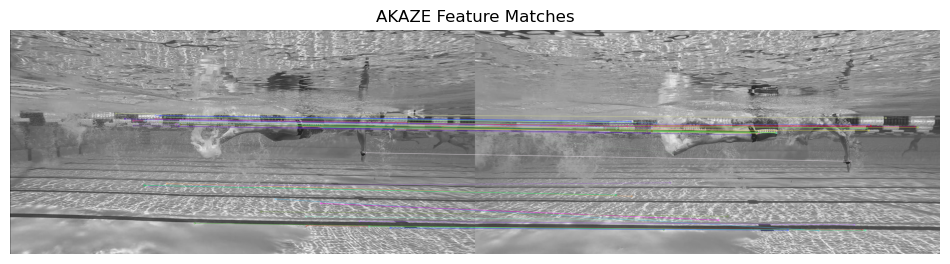

In [9]:
# Do keypoint detection and matching with AKAZE
akaze = cv2.AKAZE_create()
keypoints_t0, descriptors_t0 = akaze.detectAndCompute(img_t0, None)
keypoints_t1, descriptors_t1 = akaze.detectAndCompute(img_t1, None)

print(f"Keypoints in t0: {len(keypoints_t0)}")
print(f"Keypoints in t1: {len(keypoints_t1)}")

# Use BFMatcher with NORM_HAMMING (AKAZE uses binary descriptors)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches_knn = bf.knnMatch(descriptors_t0, descriptors_t1, k=2)

# Apply ratio test
good_matches = []
for match_pair in matches_knn:
    if len(match_pair) == 2:
        m, n = match_pair
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

matches = good_matches  # Use filtered matches for alignment
print(f"Number of good matches: {len(good_matches)}")

# Draw matches
img_matches = cv2.drawMatches(img_t0, keypoints_t0, img_t1, keypoints_t1, 
                               good_matches[:100], None, 
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12, 6))
plt.imshow(img_matches, cmap='gray')
plt.axis('off')
plt.title('AKAZE Feature Matches')
plt.show()

Using 53 keypoint pairs for alignment
RANSAC inliers: 23/53


Using 53 keypoint pairs for alignment
RANSAC inliers: 23/53


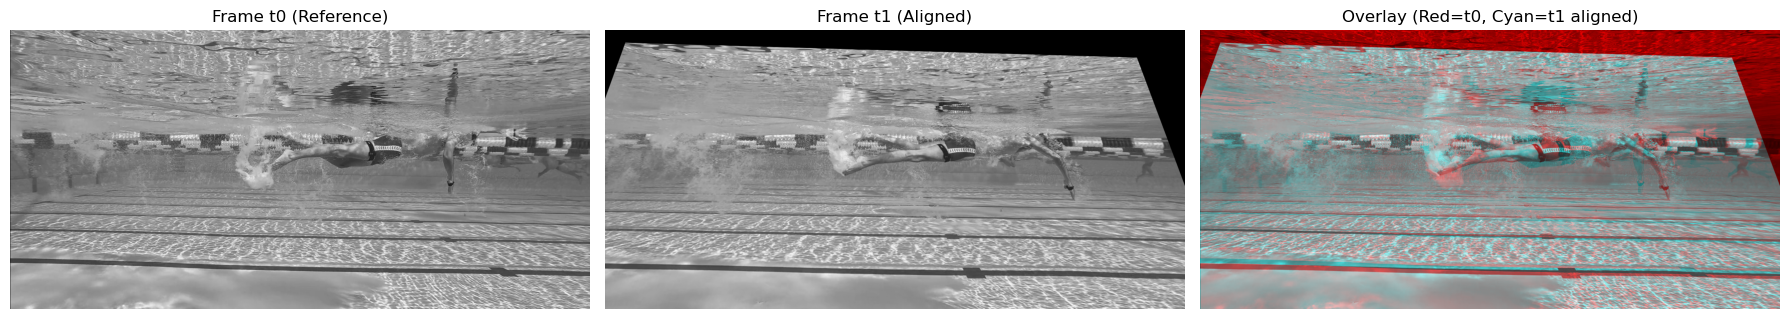

Using 53 keypoint pairs for alignment
RANSAC inliers: 23/53


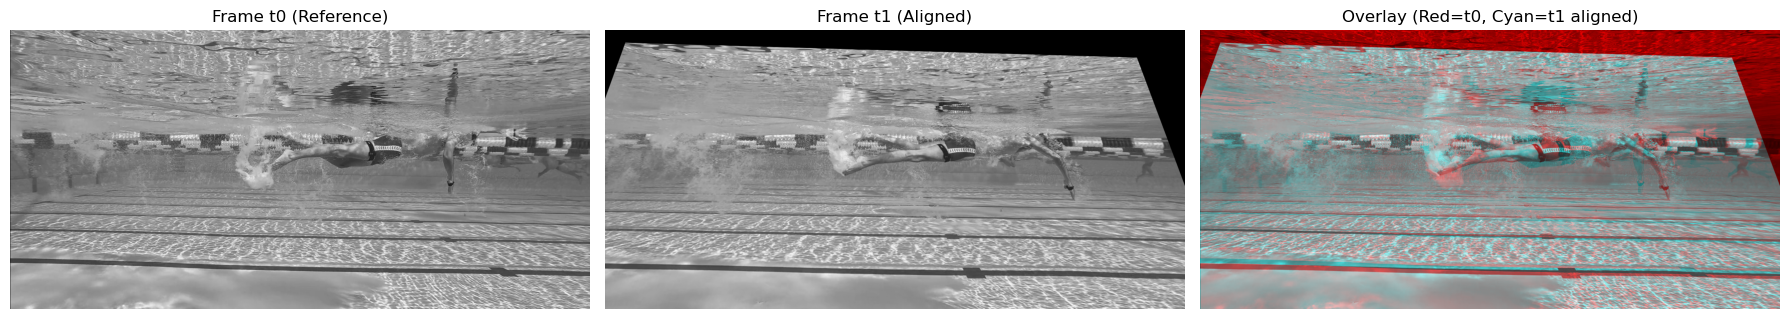

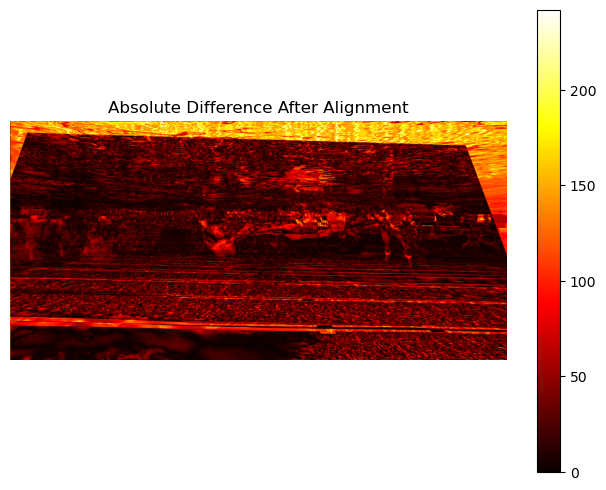

In [10]:
# Extract matched keypoint locations
pts_t0 = np.float32([keypoints_t0[m.queryIdx].pt for m in matches])
pts_t1 = np.float32([keypoints_t1[m.trainIdx].pt for m in matches])

print(f"Using {len(pts_t0)} keypoint pairs for alignment")

# Estimate homography using RANSAC
H, mask = cv2.findHomography(pts_t1, pts_t0, cv2.RANSAC, 5.0)

# Count inliers
inliers = np.sum(mask)
print(f"RANSAC inliers: {inliers}/{len(pts_t0)}")

# Warp img_t1 to align with img_t0
img_t1_aligned = cv2.warpPerspective(img_t1, H, (img_t0.shape[1], img_t0.shape[0]))

# Show aligned overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original t0
axes[0].imshow(img_t0, cmap='gray')
axes[0].set_title('Frame t0 (Reference)')
axes[0].axis('off')

# Aligned t1
axes[1].imshow(img_t1_aligned, cmap='gray')
axes[1].set_title('Frame t1 (Aligned)')
axes[1].axis('off')

# Overlay: t0 in red, t1_aligned in cyan
overlay = np.zeros((img_t0.shape[0], img_t0.shape[1], 3), dtype=np.uint8)
overlay[:, :, 0] = img_t0  # Red channel
overlay[:, :, 1] = img_t1_aligned  # Green channel
overlay[:, :, 2] = img_t1_aligned  # Blue channel (cyan = green + blue)
axes[2].imshow(overlay)
axes[2].set_title('Overlay (Red=t0, Cyan=t1 aligned)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Compute difference after alignment
diff_aligned = cv2.absdiff(img_t0, img_t1_aligned)
plt.figure(figsize=(8, 6))
plt.imshow(diff_aligned, cmap='hot')
plt.title('Absolute Difference After Alignment')
plt.colorbar()
plt.axis('off')
plt.show()

## Video Processing
Process entire video with frame alignment

In [11]:
# Load video
video_path = 'p25_FREE_UNDER_10s.mp4'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"ERROR: Could not open video {video_path}")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps
    
    print(f"Video loaded successfully:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Frame count: {frame_count}")
    print(f"  Duration: {duration:.2f} seconds")
    
    cap.release()

Video loaded successfully:
  Resolution: 1920x1080
  FPS: 30.0
  Frame count: 301
  Duration: 10.03 seconds


Processed frame 30/301 (788 matches)
Processed frame 60/301 (444 matches)
Processed frame 60/301 (444 matches)
Processed frame 90/301 (142 matches)
Processed frame 90/301 (142 matches)
Processed frame 120/301 (91 matches)
Processed frame 120/301 (91 matches)
Processed frame 150/301 (55 matches)
Processed frame 150/301 (55 matches)
Processed frame 180/301 (57 matches)
Processed frame 180/301 (57 matches)
Processed frame 210/301 (11 matches)
Processed frame 210/301 (11 matches)
Frame 214: Not enough matches (3), skipping alignment
Frame 214: Not enough matches (3), skipping alignment
Processed frame 240/301 (782 matches)
Processed frame 240/301 (782 matches)
Processed frame 270/301 (186 matches)
Processed frame 270/301 (186 matches)

Video processing complete!
Aligned video saved to: p25_aligned.mp4
Total frames processed: 300

Video processing complete!
Aligned video saved to: p25_aligned.mp4
Total frames processed: 300


Processed frame 30/301 (788 matches)
Processed frame 60/301 (444 matches)
Processed frame 60/301 (444 matches)
Processed frame 90/301 (142 matches)
Processed frame 90/301 (142 matches)
Processed frame 120/301 (91 matches)
Processed frame 120/301 (91 matches)
Processed frame 150/301 (55 matches)
Processed frame 150/301 (55 matches)
Processed frame 180/301 (57 matches)
Processed frame 180/301 (57 matches)
Processed frame 210/301 (11 matches)
Processed frame 210/301 (11 matches)
Frame 214: Not enough matches (3), skipping alignment
Frame 214: Not enough matches (3), skipping alignment
Processed frame 240/301 (782 matches)
Processed frame 240/301 (782 matches)
Processed frame 270/301 (186 matches)
Processed frame 270/301 (186 matches)

Video processing complete!
Aligned video saved to: p25_aligned.mp4
Total frames processed: 300

Video processing complete!
Aligned video saved to: p25_aligned.mp4
Total frames processed: 300


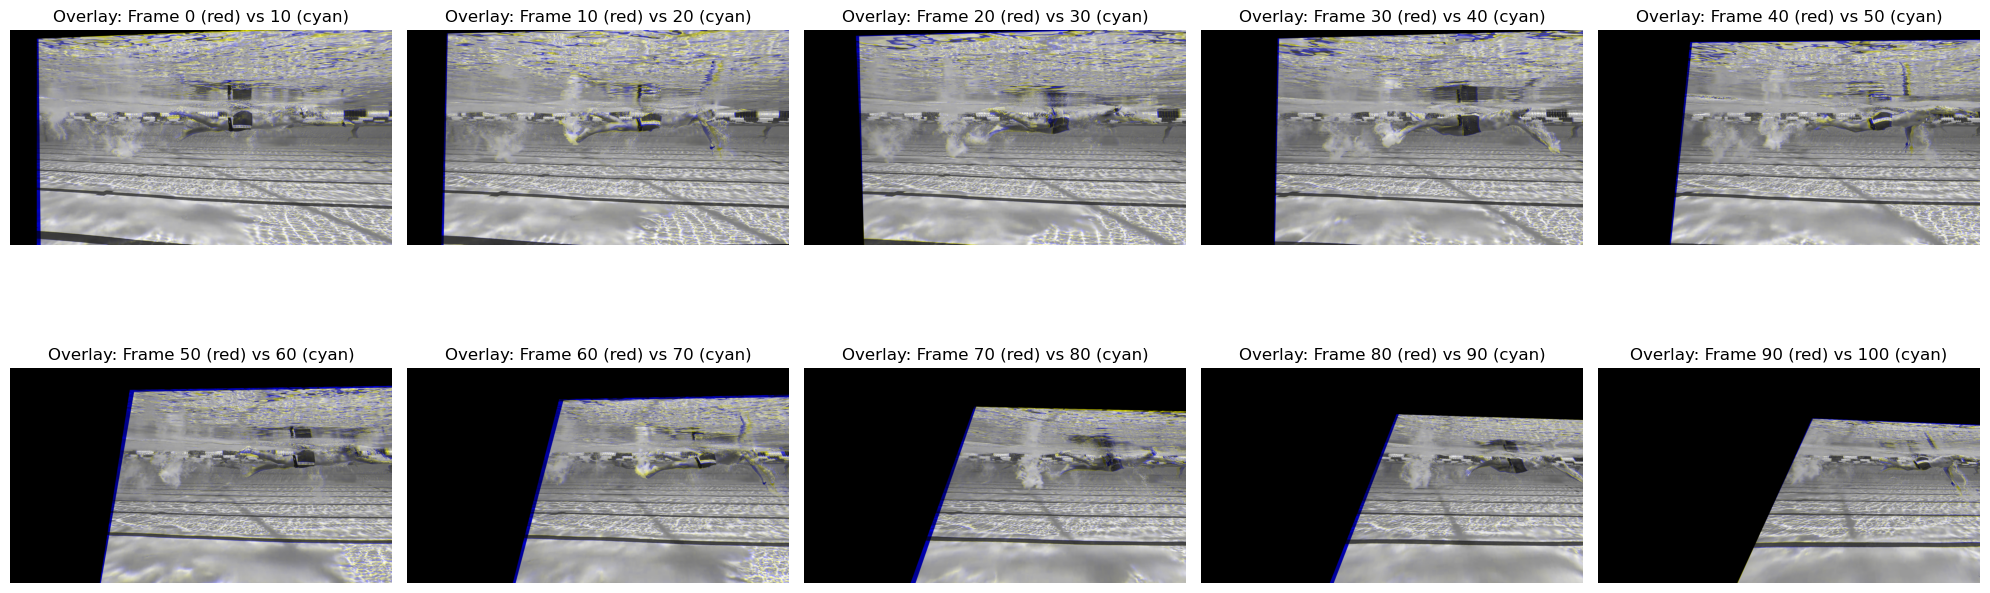

In [12]:
# Process video: align consecutive frames
cap = cv2.VideoCapture(video_path)

# Read first frame
ret, prev_frame = cap.read()
if not ret:
    print("ERROR: Could not read first frame")
    cap.release()
else:
    # Create output video writer
    output_path = 'p25_aligned.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Write first frame (no alignment needed)
    out.write(prev_frame)
    
    frame_idx = 1
    aligned_overlays = []  # Store overlays instead of just frames
    
    # Convert previous frame to grayscale for matching
    prev_frame_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    
    # Detect keypoints in previous frame
    akaze = cv2.AKAZE_create()
    prev_keypoints, prev_descriptors = akaze.detectAndCompute(prev_frame_gray, None)
    
    # Store previous frame for overlay creation
    prev_frame_for_overlay = prev_frame.copy()
    
    # Process remaining frames
    while True:
        ret, curr_frame = cap.read()
        if not ret:
            break
        
        curr_frame_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
        
        # Detect keypoints in current frame
        curr_keypoints, curr_descriptors = akaze.detectAndCompute(curr_frame_gray, None)
        
        # Match with previous frame
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        matches_knn = bf.knnMatch(prev_descriptors, curr_descriptors, k=2)
        
        # Apply ratio test
        good_matches = []
        for match_pair in matches_knn:
            if len(match_pair) == 2:
                m, n = match_pair
                if m.distance < 0.7 * n.distance:
                    good_matches.append(m)
        
        # Align frame if enough matches found
        if len(good_matches) >= 10:
            pts_prev = np.float32([prev_keypoints[m.queryIdx].pt for m in good_matches])
            pts_curr = np.float32([curr_keypoints[m.trainIdx].pt for m in good_matches])
            
            H, mask = cv2.findHomography(pts_curr, pts_prev, cv2.RANSAC, 5.0)
            
            if H is not None:
                aligned_frame = cv2.warpPerspective(curr_frame, H, (width, height))
                out.write(aligned_frame)
                
                # Create overlay every 10 frames
                if frame_idx % 10 == 0:
                    # Create red/cyan overlay
                    overlay = np.zeros((height, width, 3), dtype=np.uint8)
                    overlay[:, :, 2] = cv2.cvtColor(prev_frame_for_overlay, cv2.COLOR_BGR2GRAY)  # Red channel (prev)
                    overlay[:, :, 0] = cv2.cvtColor(aligned_frame, cv2.COLOR_BGR2GRAY)  # Blue channel (curr)
                    overlay[:, :, 1] = cv2.cvtColor(aligned_frame, cv2.COLOR_BGR2GRAY)  # Green channel (curr)
                    aligned_overlays.append(overlay)
                
                # Update previous frame to aligned frame for next iteration
                prev_frame = aligned_frame
                prev_frame_for_overlay = aligned_frame.copy()
                prev_frame_gray = cv2.cvtColor(aligned_frame, cv2.COLOR_BGR2GRAY)
                prev_keypoints, prev_descriptors = akaze.detectAndCompute(prev_frame_gray, None)
            else:
                out.write(curr_frame)  # Write original if homography fails
                
                if frame_idx % 10 == 0:
                    # Create overlay with unaligned frame
                    overlay = np.zeros((height, width, 3), dtype=np.uint8)
                    overlay[:, :, 2] = cv2.cvtColor(prev_frame_for_overlay, cv2.COLOR_BGR2GRAY)
                    overlay[:, :, 0] = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
                    overlay[:, :, 1] = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
                    aligned_overlays.append(overlay)
                
                # Update previous frame to current frame
                prev_frame = curr_frame
                prev_frame_for_overlay = curr_frame.copy()
                prev_frame_gray = curr_frame_gray
                prev_keypoints = curr_keypoints
                prev_descriptors = curr_descriptors
        else:
            print(f"Frame {frame_idx}: Not enough matches ({len(good_matches)}), skipping alignment")
            out.write(curr_frame)
            
            if frame_idx % 10 == 0:
                # Create overlay with unaligned frame
                overlay = np.zeros((height, width, 3), dtype=np.uint8)
                overlay[:, :, 2] = cv2.cvtColor(prev_frame_for_overlay, cv2.COLOR_BGR2GRAY)
                overlay[:, :, 0] = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
                overlay[:, :, 1] = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
                aligned_overlays.append(overlay)
            
            # Update previous frame to current frame
            prev_frame = curr_frame
            prev_frame_for_overlay = curr_frame.copy()
            prev_frame_gray = curr_frame_gray
            prev_keypoints = curr_keypoints
            prev_descriptors = curr_descriptors
        
        if frame_idx % 30 == 0:
            print(f"Processed frame {frame_idx}/{frame_count} ({len(good_matches)} matches)")
        
        frame_idx += 1
    
    cap.release()
    out.release()
    
    print(f"\nVideo processing complete!")
    print(f"Aligned video saved to: {output_path}")
    print(f"Total frames processed: {frame_idx}")
    
    # Show sample overlays (red = previous frame, cyan = current aligned frame)
    num_samples = min(10, len(aligned_overlays))
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i in range(num_samples):
        axes[i].imshow(aligned_overlays[i])
        axes[i].set_title(f'Overlay: Frame {(i+1)*10-10} (red) vs {(i+1)*10} (cyan)')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_samples, 10):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()